In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
def load_images_from_folder(folder):
    images = []
    for filename in sorted(os.listdir(folder)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img = cv2.imread(os.path.join(folder, filename))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
    return np.array(images)

dir1_path = "drive/MyDrive/hackathon_3_problemm/dir1"
img = load_images_from_folder(dir1_path)[0]

In [11]:
def local_variance(gray, ksize=7):
    gray = gray.astype(np.float32)
    mean = cv2.blur(gray, (ksize, ksize))
    mean_sq = cv2.blur(gray*gray, (ksize, ksize))
    return mean_sq - mean*mean

In [12]:
def cloud_mask_binary(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]

    _, mask_v = cv2.threshold(V, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, mask_s = cv2.threshold(S, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    mask_bin = cv2.bitwise_and(mask_v, mask_s)
    mask_bin = (mask_bin > 0).astype(np.uint8)

    return mask_bin

In [13]:
def cloud_mask_ternary(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]

    _, mask_v = cv2.threshold(V, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, mask_s = cv2.threshold(S, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    mask_bin = cv2.bitwise_and(mask_v, mask_s)
    mask_bin = (mask_bin > 0).astype(np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    var = local_variance(gray, ksize=7)

    cloud_pixels = var[mask_bin == 1]
    if len(cloud_pixels) == 0:
        return mask_bin

    T = np.percentile(cloud_pixels, 40)

    tern = np.zeros_like(mask_bin)
    tern[(mask_bin == 1) & (var < T)] = 1
    tern[(mask_bin == 1) & (var >= T)] = 2

    return tern

In [14]:
def extract_edges(mask):
    edges = cv2.Canny((mask*255).astype(np.uint8), 50, 150)
    return edges

In [15]:
def extract_edges_ternary(mask):
    mask_norm = (mask * (255//2)).astype(np.uint8)
    edges = cv2.Canny(mask_norm, 50, 150)
    return edges

In [16]:
binary_mask = cloud_mask_binary(img)
ternary_mask = cloud_mask_ternary(img)

edges_binary = extract_edges(binary_mask)
edges_ternary = extract_edges_ternary(ternary_mask)


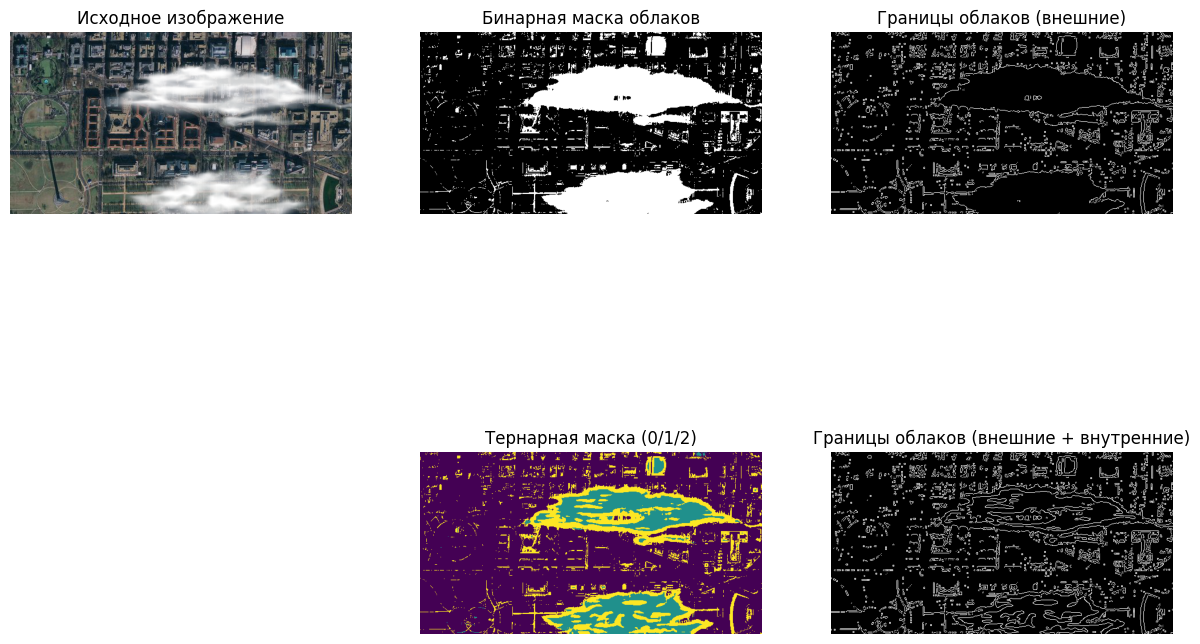

In [17]:
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(img)
plt.title("Исходное изображение")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(binary_mask, cmap='gray')
plt.title("Бинарная маска облаков")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(edges_binary, cmap='gray')
plt.title("Границы облаков (внешние)")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(ternary_mask, cmap='viridis')
plt.title("Тернарная маска (0/1/2)")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(edges_ternary, cmap='gray')
plt.title("Границы облаков (внешние + внутренние)")
plt.axis("off")

plt.show()


In [18]:
# Сохранение бинарной маски
plt.imsave("binary_mask.png", binary_mask, cmap='gray')
cv2.imwrite("binary_mask_cv2.png", (binary_mask * 255).astype(np.uint8))

# Сохранение тернарной маски
plt.imsave("ternary_mask.png", ternary_mask, cmap='viridis')
np.save("ternary_mask.npy", ternary_mask)